In [ ]:
#To run this code, you need to upload the 'sionna_dg.py' file to the environment.

In [3]:
pip install sionna tensorflow

Using Device: cpu


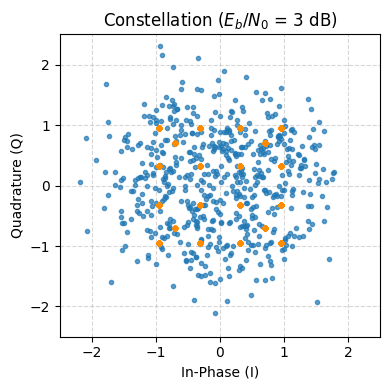

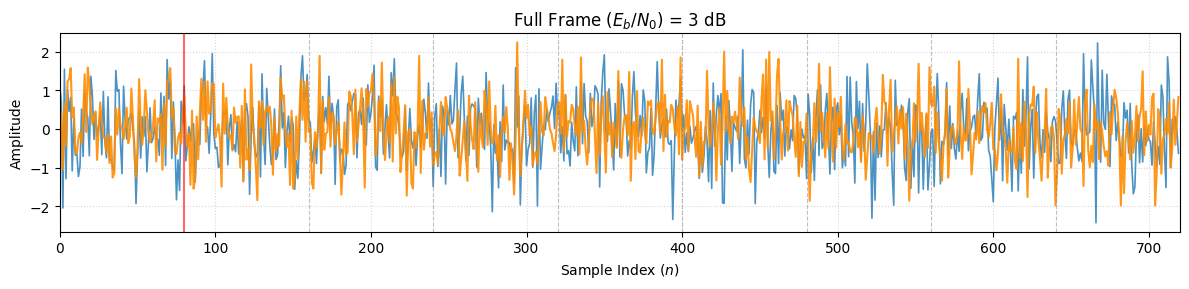

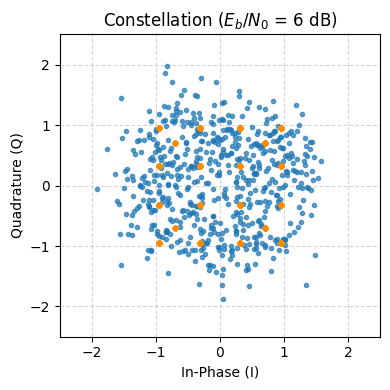

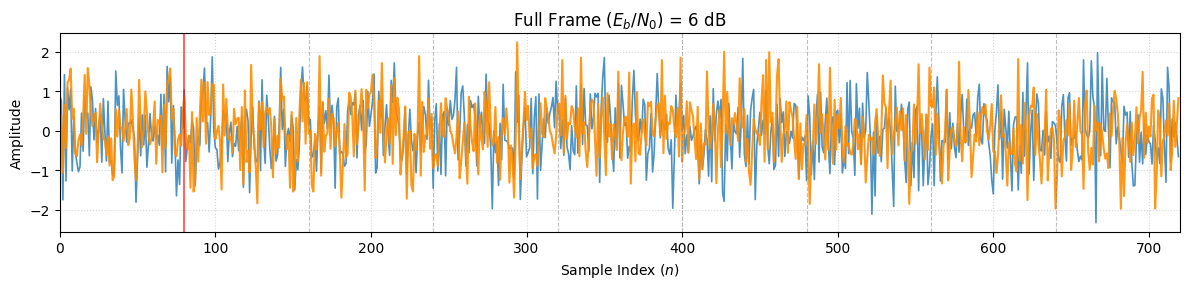

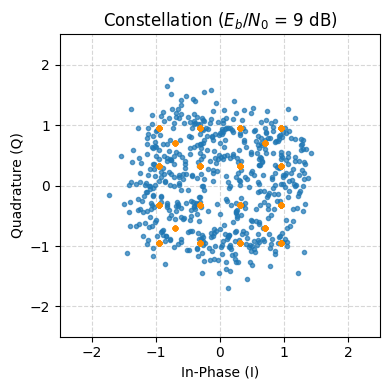

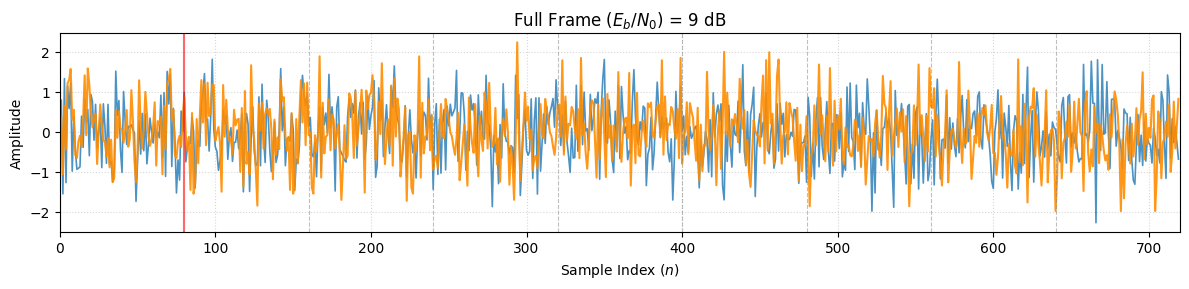

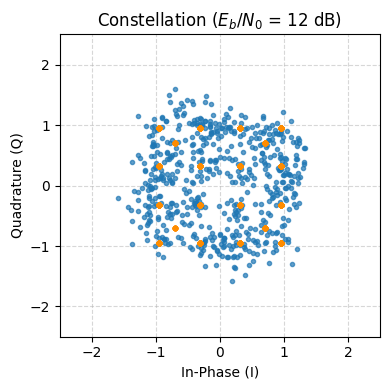

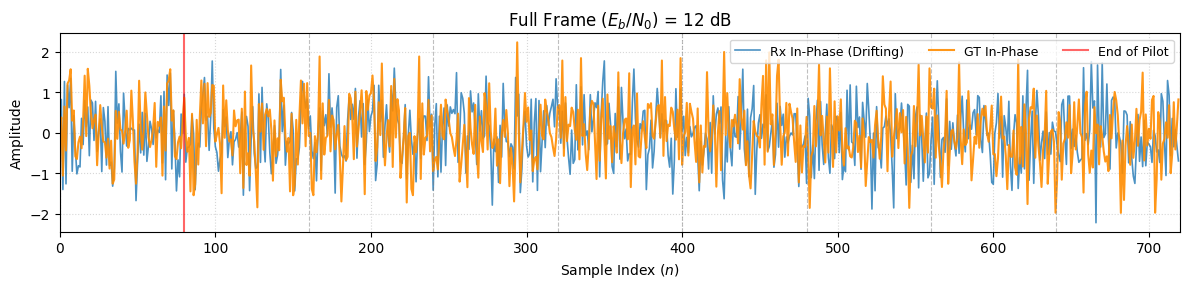

All 8 plots generated and saved as PDFs.


In [5]:
# ==========================================
# STANDALONE CELL: OFDM DATA VISUALIZATION (8 SEPARATE PLOTS)
# ==========================================
import torch
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Import local functions from sionna_dg.py
from sionna_dg import SimConfig, simulate_full_frames_ofdm_tf

torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

snr_levels = [3.0, 6.0, 9.0, 12.0]

for snr in snr_levels:
    # 1. Configuration variable
    cfg_eval = SimConfig(
        num_examples=1,
        bits_per_symbol=4,
        k=1024,
        seq_length=512,
        demap_method="app",
        dec_num_iter=15,
        cn_update="minsum",
        seed=46,
        channels_last=True,
        cfo_mode="direct",
        cfo_norm_min=2e-4,           # Force max CFO for visual impact
        cfo_norm_max=2e-4,           # Force max CFO for visual impact
        ebn0_db_min=snr,
        ebn0_db_max=snr,
        include_pilot_overhead_in_no=True,
        waveform="ofdm",
        ofdm_fft_size=64,
        ofdm_cp_len=16,
        ofdm_num_data_symbols=8,
        ofdm_num_pilot_symbols=1,
    )

    # Calculate exact time-domain sequence length: (1 pilot + 8 data) * (64 FFT + 16 CP) = 720
    num_time_samples = (cfg_eval.ofdm_num_pilot_symbols + cfg_eval.ofdm_num_data_symbols) * (cfg_eval.ofdm_fft_size + cfg_eval.ofdm_cp_len)

    # 2. Simulate the frame
    out = simulate_full_frames_ofdm_tf(cfg_eval)

    # 3. Extract tensors to numpy
    x_tx = out["x_tx"][0].numpy()
    y_rx = out["y_rx"][0].numpy()
    x_grid = out["x_grid"][0].numpy()

    # 4. Receiver DSP: CP Removal + FFT to recover frequency-domain constellation
    num_symbols = cfg_eval.ofdm_num_pilot_symbols + cfg_eval.ofdm_num_data_symbols
    y_rx_reshaped = y_rx.reshape(num_symbols, cfg_eval.ofdm_fft_size + cfg_eval.ofdm_cp_len)
    y_rx_no_cp = y_rx_reshaped[:, cfg_eval.ofdm_cp_len:]
    y_rx_grid = np.fft.fft(y_rx_no_cp, axis=-1) / np.sqrt(cfg_eval.ofdm_fft_size)

    clean_constellation = x_grid.flatten()
    rx_constellation = y_rx_grid.flatten()

    # ==========================================
    # FIGURE A: Constellation Diagram (Dots)
    # ==========================================
    fig_const = plt.figure(figsize=(4, 4))

    # Received (Blue) plotted first so Ground Truth (Orange) sits on top
    plt.plot(rx_constellation.real, rx_constellation.imag,
             marker='.', linestyle='', color='tab:blue', markersize=6, alpha=0.7, label='Rx (Noisy+CFO)')

    plt.plot(clean_constellation.real, clean_constellation.imag,
             marker='.', linestyle='', color='darkorange', markersize=6, alpha=1.0, label='GT (Clean)')

    plt.title(f'Constellation ($E_b/N_0$ = {int(snr)} dB)', fontsize=12)
    plt.xlabel('In-Phase (I)')
    plt.ylabel('Quadrature (Q)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim([-2.5, 2.5])
    plt.ylim([-2.5, 2.5])
    plt.tight_layout()

    plt.show()

    # ==========================================
    # FIGURE B: Time-Domain Signal (FULL 720 SAMPLES)
    # ==========================================
    fig_time = plt.figure(figsize=(12, 3))
    t_axis = np.arange(num_time_samples)

    # Received (Blue)
    plt.plot(t_axis, y_rx[:num_time_samples].real,
             linestyle='-', marker='', color='tab:blue', linewidth=1.2, alpha=0.8, label='Rx In-Phase (Drifting)')

    # Ground Truth (Orange)
    plt.plot(t_axis, x_tx[:num_time_samples].real,
             linestyle='-', marker='', color='darkorange', linewidth=1.5, alpha=0.9, label='GT In-Phase')

    # Add vertical lines to show the OFDM symbol boundaries (Pilot vs Data)
    for boundary in range(0, num_time_samples + 1, 80):
        if boundary == 80:
            # Highlight the end of the SINGLE pilot symbol
            plt.axvline(x=boundary, color='red', linestyle='-', linewidth=1.5, alpha=0.6, label='End of Pilot')
        else:
            plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    plt.title(f'Full Frame ($E_b/N_0$) = {int(snr)} dB', fontsize=12)
    plt.xlabel('Sample Index ($n$)')
    plt.ylabel('Amplitude')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.xlim([0, num_time_samples])

    if snr == 12.0:
        plt.legend(loc='upper right', fontsize=9, ncol=3)

    plt.tight_layout()

    plt.show()

print("All 8 plots generated and saved as PDFs.")